# Sentiment Analysis with BERT
### Fine-tuning `bert-base-uncased` on IMDB Movie Reviews
> Pretrained BERT captures deep contextual representations — far beyond what RNN/LSTM can learn from scratch.

## 1. Install & Import Dependencies

In [1]:
import os, time, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["TORCH_USE_CUDA_DSA"] = "1"

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'[DEVICE] Using: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'[GPU]    {torch.cuda.get_device_name(0)}')
    print(f'[GPU]    Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

[DEVICE] Using: cuda
[GPU]    NVIDIA GeForce RTX 4070 Laptop GPU
[GPU]    Memory: 8.6 GB


## 2. Hyperparameters
BERT fine-tuning uses much smaller learning rates than training from scratch —
we don't want to destroy the pretrained weights.

In [2]:
# ── BERT fine-tuning hyperparameters ─────────────────────────────────────────
MODEL_NAME   = 'bert-base-uncased'
MAX_LEN      = 256
BATCH_SIZE   = 16
NUM_EPOCHS   = 4
LEARNING_RATE = 2e-5
WARMUP_RATIO  = 0.1
NUM_LABELS   = 2

print('[HYPERPARAMS] Loaded.')
print(f'  Model        : {MODEL_NAME}')
print(f'  Max length   : {MAX_LEN} tokens')
print(f'  Batch size   : {BATCH_SIZE}')
print(f'  Epochs       : {NUM_EPOCHS}')
print(f'  Learning rate: {LEARNING_RATE}')
print(f'  Warmup ratio : {WARMUP_RATIO}')
print()
print('  WHY small LR? BERT is already pretrained on 3.3B words.')
print('  Large LR would destroy the learned representations.')

[HYPERPARAMS] Loaded.
  Model        : bert-base-uncased
  Max length   : 256 tokens
  Batch size   : 16
  Epochs       : 4
  Learning rate: 2e-05
  Warmup ratio : 0.1

  WHY small LR? BERT is already pretrained on 3.3B words.
  Large LR would destroy the learned representations.


## 3. Load IMDB Dataset

In [3]:
from tensorflow.keras.datasets import imdb as keras_imdb  # type: ignore

# Load the word index to decode back to text
print('[DATA]  Loading IMDB word index...')
word_index = keras_imdb.get_word_index()
# Reverse: index → word (indices are offset by 3 in keras)
idx_to_word = {v + 3: k for k, v in word_index.items()}
idx_to_word[0] = '<pad>'
idx_to_word[1] = '<sos>'
idx_to_word[2] = '<unk>'
idx_to_word[3] = '<unused>'

# Load raw integer sequences
print('[DATA]  Loading IMDB reviews...')
(x_train_raw, y_train), (x_test_raw, y_test) = keras_imdb.load_data()

def decode_review(encoded):
    """Convert keras integer sequence back to human-readable text."""
    return ' '.join(idx_to_word.get(i, '?') for i in encoded)

# Decode all reviews to text
print('[DATA]  Decoding reviews to text...')
x_train_text = [decode_review(r) for r in x_train_raw]
x_test_text  = [decode_review(r) for r in x_test_raw]

print(f'[DATA]  Train samples: {len(x_train_text):,}')
print(f'[DATA]  Test  samples: {len(x_test_text):,}')
print(f'[DATA]  Label balance (train) — pos: {y_train.sum()}, neg: {len(y_train)-y_train.sum()}')
print()
print('[SAMPLE REVIEW]:')
print(x_train_text[0][:200] + '...')
print(f'Label: {"Positive" if y_train[0] == 1 else "Negative"}')

[DATA]  Loading IMDB word index...
[DATA]  Loading IMDB reviews...
[DATA]  Decoding reviews to text...
[DATA]  Train samples: 25,000
[DATA]  Test  samples: 25,000
[DATA]  Label balance (train) — pos: 12500, neg: 12500

[SAMPLE REVIEW]:
<sos> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor an...
Label: Positive


## 4. BERT Tokenizer & Custom Dataset
BERT uses **WordPiece tokenization** — it splits unknown words into subwords.
For example: `"unhappiness"` → `["un", "##happiness"]`

Each input needs 3 tensors:
- `input_ids` — token indices
- `attention_mask` — 1 for real tokens, 0 for padding
- `token_type_ids` — 0 for single-sentence tasks

In [4]:
print(f'[TOKENIZER]  Loading {MODEL_NAME} tokenizer...')
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print(f'[TOKENIZER]  Vocab size: {tokenizer.vocab_size:,}')
print(f'[TOKENIZER]  Special tokens: [CLS]={tokenizer.cls_token_id}, '
      f'[SEP]={tokenizer.sep_token_id}, [PAD]={tokenizer.pad_token_id}')

# Show tokenization example
example = "This movie was absolutely fantastic!"
tokens  = tokenizer.tokenize(example)
print(f'\n[TOKENIZER]  Example: "{example}"')
print(f'[TOKENIZER]  Tokens : {tokens}')


class IMDBDataset(Dataset):

    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length      = self.max_len,
            padding         = 'max_length',   # pad to max_len
            truncation      = True,           # truncate if longer
            return_tensors  = 'pt'
        )
        return {
            'input_ids'     : encoding['input_ids'].squeeze(0),       # (max_len,)
            'attention_mask': encoding['attention_mask'].squeeze(0),  # (max_len,)
            'label'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }


train_dataset = IMDBDataset(x_train_text, y_train, tokenizer, MAX_LEN)
test_dataset  = IMDBDataset(x_test_text,  y_test,  tokenizer, MAX_LEN)

PIN = (DEVICE.type == 'cuda')
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)

print(f'\n[DATALOADER]  Train batches: {len(train_loader)}')
print(f'[DATALOADER]  Test  batches: {len(test_loader)}')

[TOKENIZER]  Loading bert-base-uncased tokenizer...
[TOKENIZER]  Vocab size: 30,522
[TOKENIZER]  Special tokens: [CLS]=101, [SEP]=102, [PAD]=0

[TOKENIZER]  Example: "This movie was absolutely fantastic!"
[TOKENIZER]  Tokens : ['this', 'movie', 'was', 'absolutely', 'fantastic', '!']

[DATALOADER]  Train batches: 1563
[DATALOADER]  Test  batches: 1563


## 5. Load Pretrained BERT Model
`BertForSequenceClassification` = BERT + linear classification head on top of [CLS] token.

In [5]:
print(f'[MODEL]  Loading pretrained {MODEL_NAME}...')
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels          = NUM_LABELS,
    output_attentions   = False,
    output_hidden_states= False
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'[MODEL]  Total parameters     : {total_params:,}')
print(f'[MODEL]  Trainable parameters : {trainable_params:,}')
print(f'[MODEL]  Architecture         : BERT-base + Classification Head')
print(f'[MODEL]  BERT layers          : 12 transformer blocks')
print(f'[MODEL]  Hidden size          : 768')
print(f'[MODEL]  Attention heads      : 12')
print()
print('  HOW IT WORKS:')
print('  Input → [CLS] token_1 token_2 ... [SEP]')
print('  [CLS] final hidden state → Linear(768, 2) → softmax → label')

[MODEL]  Loading pretrained bert-base-uncased...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[MODEL]  Total parameters     : 109,483,778
[MODEL]  Trainable parameters : 109,483,778
[MODEL]  Architecture         : BERT-base + Classification Head
[MODEL]  BERT layers          : 12 transformer blocks
[MODEL]  Hidden size          : 768
[MODEL]  Attention heads      : 12

  HOW IT WORKS:
  Input → [CLS] token_1 token_2 ... [SEP]
  [CLS] final hidden state → Linear(768, 2) → softmax → label


## 6. Optimizer & Scheduler
We use **AdamW** (Adam with weight decay) — standard for BERT fine-tuning.
**Linear warmup scheduler** gradually increases LR for the first 10% of steps,
then linearly decays — this stabilizes early training.

In [6]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = LEARNING_RATE,
    weight_decay = 0.01   # L2 regularization
)

total_steps  = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)

print(f'[OPTIMIZER]  AdamW  |  LR={LEARNING_RATE}  |  weight_decay=0.01')
print(f'[SCHEDULER]  Linear warmup + decay')
print(f'[SCHEDULER]  Total steps  : {total_steps:,}')
print(f'[SCHEDULER]  Warmup steps : {warmup_steps:,}  ({WARMUP_RATIO*100:.0f}% of total)')

[OPTIMIZER]  AdamW  |  LR=2e-05  |  weight_decay=0.01
[SCHEDULER]  Linear warmup + decay
[SCHEDULER]  Total steps  : 6,252
[SCHEDULER]  Warmup steps : 625  (10% of total)


## 7. Training & Evaluation Functions

In [7]:
ACCUMULATION_STEPS = 2

def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    optimizer.zero_grad()

    for batch_idx, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['label'].to(DEVICE)

        # Forward pass
        outputs = model(
            input_ids      = input_ids,
            attention_mask = attention_mask,
            labels         = labels
        )

        loss   = outputs.loss / ACCUMULATION_STEPS
        logits = outputs.logits

        loss.backward()

        if (batch_idx + 1) % ACCUMULATION_STEPS == 0:
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()  #

        preds = logits.argmax(dim=1)
        total_loss += outputs.loss.item() * len(labels)
        correct    += (preds == labels).sum().item()
        total      += len(labels)

        if (batch_idx + 1) % 200 == 0:
            print(f'  [Batch {batch_idx+1:4d}/{len(loader)}] '
                  f'Loss: {outputs.loss.item():.4f}  '
                  f'LR: {scheduler.get_last_lr()[0]:.2e}')

    return total_loss / total, correct / total


def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels         = batch['label'].to(DEVICE)

            outputs = model(
                input_ids      = input_ids,
                attention_mask = attention_mask,
                labels         = labels
            )
            preds = outputs.logits.argmax(dim=1)

            total_loss += outputs.loss.item() * len(labels)
            correct    += (preds == labels).sum().item()
            total      += len(labels)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, all_preds, all_labels


print('[FUNCTIONS]  train_epoch and evaluate defined.')

[FUNCTIONS]  train_epoch and evaluate defined.


## 8. Fine-Tuning Loop

In [8]:
BEST_MODEL_PATH = 'bert_imdb_best.pt'
best_val_acc    = 0.0
train_losses, train_accs = [], []
val_losses,   val_accs   = [], []

print('=' * 65)
print(f'  Fine-tuning {MODEL_NAME} on IMDB')
print(f'  Epochs: {NUM_EPOCHS}  |  Batch: {BATCH_SIZE}  |  LR: {LEARNING_RATE}')
print('=' * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    torch.cuda.empty_cache()
    t0 = time.time()
    print(f'\n--- Epoch {epoch}/{NUM_EPOCHS} ---')

    tr_loss, tr_acc      = train_epoch(model, train_loader, optimizer, scheduler)
    va_loss, va_acc, _, _ = evaluate(model, test_loader)

    train_losses.append(tr_loss); train_accs.append(tr_acc)
    val_losses.append(va_loss);   val_accs.append(va_acc)

    saved = ''
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        saved = '  ✓ Best model saved!'

    print(f'\nEpoch {epoch}/{NUM_EPOCHS} | '
          f'Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | '
          f'Val Loss: {va_loss:.4f}  Acc: {va_acc:.4f} | '
          f'{time.time()-t0:.1f}s{saved}')

print('\n' + '=' * 65)
print(f'  Fine-tuning complete! Best Val Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')
print('=' * 65)

  Fine-tuning bert-base-uncased on IMDB
  Epochs: 4  |  Batch: 16  |  LR: 2e-05

--- Epoch 1/4 ---
  [Batch  200/1563] Loss: 0.7001  LR: 3.20e-06
  [Batch  400/1563] Loss: 0.4017  LR: 6.40e-06
  [Batch  600/1563] Loss: 0.3441  LR: 9.60e-06
  [Batch  800/1563] Loss: 0.2764  LR: 1.28e-05
  [Batch 1000/1563] Loss: 0.1684  LR: 1.60e-05
  [Batch 1200/1563] Loss: 0.3737  LR: 1.92e-05
  [Batch 1400/1563] Loss: 0.0884  LR: 1.97e-05

Epoch 1/4 | Train Loss: 0.3664  Acc: 0.8290 | Val Loss: 0.2339  Acc: 0.9091 | 771.1s  ✓ Best model saved!

--- Epoch 2/4 ---
  [Batch  200/1563] Loss: 0.3466  LR: 1.91e-05
  [Batch  400/1563] Loss: 0.0538  LR: 1.87e-05
  [Batch  600/1563] Loss: 0.0325  LR: 1.84e-05
  [Batch  800/1563] Loss: 0.2066  LR: 1.80e-05
  [Batch 1000/1563] Loss: 0.0583  LR: 1.77e-05
  [Batch 1200/1563] Loss: 0.0415  LR: 1.73e-05
  [Batch 1400/1563] Loss: 0.1662  LR: 1.70e-05

Epoch 2/4 | Train Loss: 0.1925  Acc: 0.9273 | Val Loss: 0.2072  Acc: 0.9211 | 784.8s  ✓ Best model saved!

--- Epoch

## 9. Training Curves

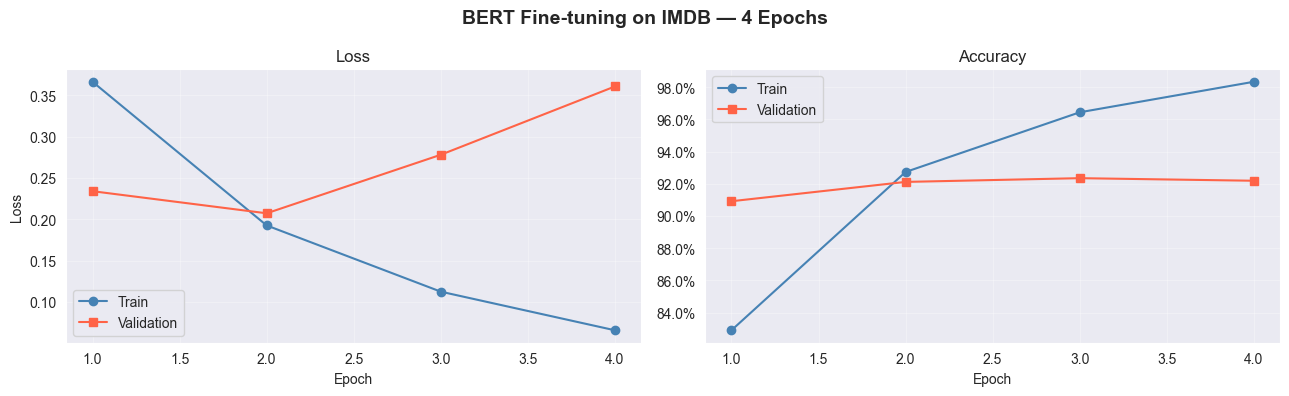

In [9]:
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'BERT Fine-tuning on IMDB — {NUM_EPOCHS} Epochs',
             fontsize=14, fontweight='bold')

axes[0].plot(epochs, train_losses, '-o', color='steelblue', label='Train')
axes[0].plot(epochs, val_losses,   '-s', color='tomato',    label='Validation')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, train_accs, '-o', color='steelblue', label='Train')
axes[1].plot(epochs, val_accs,   '-s', color='tomato',    label='Validation')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 10. Evaluation Metrics on Test Set

In [10]:
# Load best model before final evaluation
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
print(f'[EVAL]  Loaded best model: {BEST_MODEL_PATH}')
print('[EVAL]  Running evaluation on test set...\n')

_, acc, preds, labels = evaluate(model, test_loader)

prec = precision_score(labels, preds, zero_division=0)
rec  = recall_score(labels,    preds, zero_division=0)
f1   = f1_score(labels,        preds, zero_division=0)
cm   = confusion_matrix(labels, preds)

print('=' * 50)
print('  BERT — TEST SET METRICS')
print('=' * 50)
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print('=' * 50)
print()
print(classification_report(labels, preds,
                              target_names=['Negative', 'Positive']))

[EVAL]  Loaded best model: bert_imdb_best.pt
[EVAL]  Running evaluation on test set...

  BERT — TEST SET METRICS
  Accuracy  : 0.9234  (92.34%)
  Precision : 0.9119
  Recall    : 0.9374
  F1-Score  : 0.9245

              precision    recall  f1-score   support

    Negative       0.94      0.91      0.92     12500
    Positive       0.91      0.94      0.92     12500

    accuracy                           0.92     25000
   macro avg       0.92      0.92      0.92     25000
weighted avg       0.92      0.92      0.92     25000



## 11. Confusion Matrix

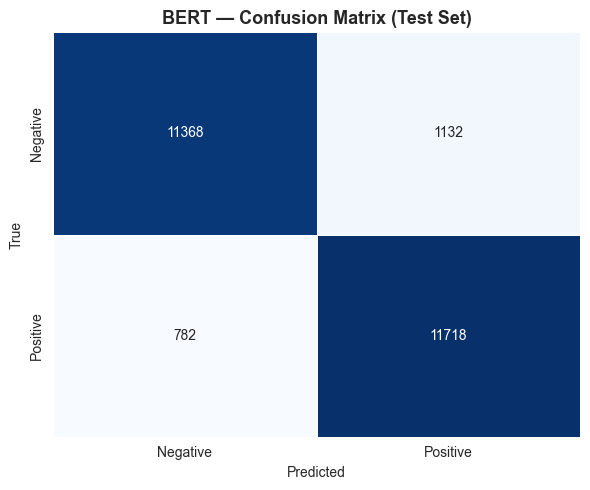

  True Negatives  : 11,368
  False Positives : 1,132
  False Negatives : 782
  True Positives  : 11,718


In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            linewidths=0.5, cbar=False)
ax.set_title('BERT — Confusion Matrix (Test Set)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'  True Negatives  : {tn:,}')
print(f'  False Positives : {fp:,}')
print(f'  False Negatives : {fn:,}')
print(f'  True Positives  : {tp:,}')

## 12. Comparison with Task 4 — RNN vs LSTM vs GRU vs BERT

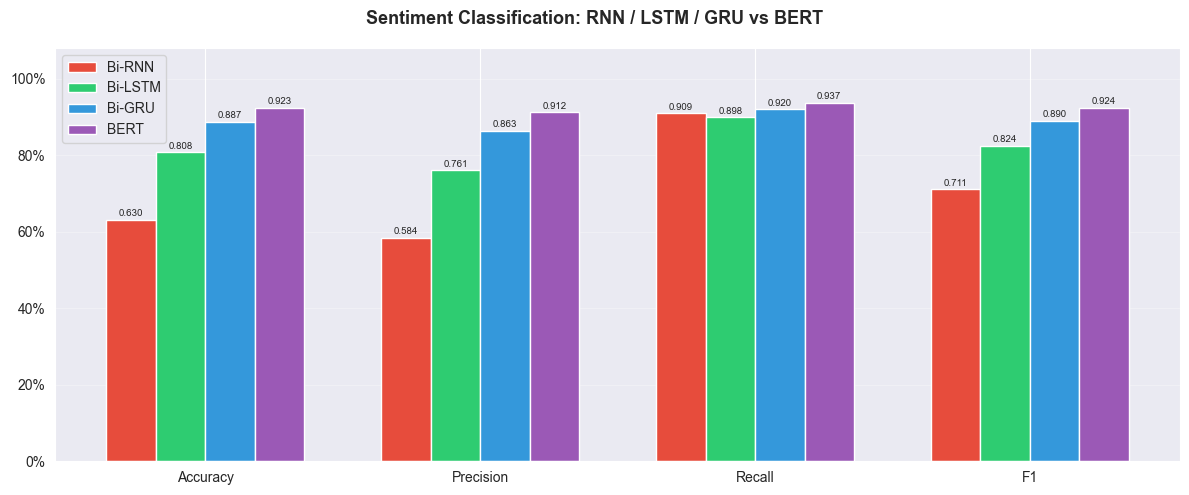

In [12]:
# Task 4 results — update with your actual Task 4 numbers
task4_results = {
    'Bi-RNN' : {'accuracy': 0.6305, 'precision': 0.5838, 'recall': 0.9094, 'f1': 0.7111},
    'Bi-LSTM': {'accuracy': 0.8080, 'precision': 0.7609, 'recall': 0.8984, 'f1': 0.8239},
    'Bi-GRU' : {'accuracy': 0.8869, 'precision': 0.8631, 'recall': 0.9198, 'f1': 0.8905},
    'BERT'   : {'accuracy': acc,    'precision': prec,   'recall': rec,    'f1': f1},
}

metrics = ['accuracy', 'precision', 'recall', 'f1']
models  = list(task4_results.keys())
colors  = ['#E74C3C', '#2ECC71', '#3498DB', '#9B59B6']

x      = np.arange(len(metrics))
width  = 0.18
offsets = [-1.5, -0.5, 0.5, 1.5]

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Sentiment Classification: RNN / LSTM / GRU vs BERT',
             fontsize=13, fontweight='bold')

for i, (name, res) in enumerate(task4_results.items()):
    vals = [res[m] for m in metrics]
    bars = ax.bar(x + offsets[i]*width, vals, width,
                  label=name, color=colors[i], edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in metrics])
ax.set_ylim(0, 1.08)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 13. Final Summary

In [13]:
print('=' * 62)
print('              FINAL SUMMARY')
print('=' * 62)
print(f"  {'Model':<10} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
print('-' * 62)
for name, res in task4_results.items():
    marker = ' ← BERT' if name == 'BERT' else ''
    print(f"  {name:<10} {res['accuracy']:>8.4f} {res['precision']:>8.4f} "
          f"{res['recall']:>8.4f} {res['f1']:>8.4f}{marker}")
print('=' * 62)

bert_acc = task4_results['BERT']['accuracy']
gru_acc  = task4_results['Bi-GRU']['accuracy']
print(f'\n  BERT vs Best RNN (Bi-GRU): +{(bert_acc - gru_acc)*100:.2f}% accuracy')
print()
print('  Why BERT outperforms RNN/LSTM/GRU:')
print('  • Pretrained on 3.3B words — deep language understanding')
print('  • Bidirectional transformer attention (not sequential)')
print('  • [CLS] token captures full sentence meaning')
print('  • Fine-tuning only 4 epochs — leverages pretrained knowledge')
print('=' * 62)

              FINAL SUMMARY
  Model           Acc     Prec      Rec       F1
--------------------------------------------------------------
  Bi-RNN       0.6305   0.5838   0.9094   0.7111
  Bi-LSTM      0.8080   0.7609   0.8984   0.8239
  Bi-GRU       0.8869   0.8631   0.9198   0.8905
  BERT         0.9234   0.9119   0.9374   0.9245 ← BERT

  BERT vs Best RNN (Bi-GRU): +3.65% accuracy

  Why BERT outperforms RNN/LSTM/GRU:
  • Pretrained on 3.3B words — deep language understanding
  • Bidirectional transformer attention (not sequential)
  • [CLS] token captures full sentence meaning
  • Fine-tuning only 4 epochs — leverages pretrained knowledge


## 14. Inference — Custom Text Prediction

In [14]:
def predict(text, model, tokenizer, device):
    model.eval()
    encoding = tokenizer(
        text,
        max_length     = MAX_LEN,
        padding        = 'max_length',
        truncation     = True,
        return_tensors = 'pt'
    )

    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

    probs      = torch.softmax(outputs.logits, dim=1)
    pred_label = probs.argmax(dim=1).item()
    confidence = probs[0][pred_label].item()

    label = "Positive 😊" if pred_label == 1 else "Negative 😞"
    print(f"Text       : {text[:80]}...")
    print(f"Prediction : {label}")
    print(f"Confidence : {confidence*100:.2f}%")
    print()


predict("This movie was absolutely fantastic! Best film I've seen in years.", model, tokenizer, DEVICE)
predict("Terrible movie, complete waste of time. The plot made no sense.", model, tokenizer, DEVICE)
predict("It was okay, nothing special but not awful either.",               model, tokenizer, DEVICE)

Text       : This movie was absolutely fantastic! Best film I've seen in years....
Prediction : Positive 😊
Confidence : 99.35%

Text       : Terrible movie, complete waste of time. The plot made no sense....
Prediction : Negative 😞
Confidence : 99.43%

Text       : It was okay, nothing special but not awful either....
Prediction : Negative 😞
Confidence : 76.39%

